In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.
from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them
from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting
from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models

In [60]:
df = pd.read_csv("mnist_train.csv")
df_test = pd.read_csv("mnist_test.csv")

In [61]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [62]:
df['label'].value_counts()

,count
label,
1,4684
7,4401
3,4351
9,4188
2,4177
6,4137
0,4132
4,4072
8,4063


In [63]:
#preprocess
X_train = df.drop("label", axis=1).values
y_train = df["label"].values
X_test = df_test.drop("label", axis=1).values
y_test = df_test["label"].values

In [64]:
X = df.drop('label', axis=1)
y = df['label']

In [65]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [66]:
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)

In [67]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [68]:
perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation="softmax")
])

In [69]:
perceptron.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
history_percp = perceptron.fit(X_train_img, y_train_cat, epochs=5, batch_size=32,
                               validation_data=(X_test_img, y_test_cat), verbose=1)

Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8649 - loss: 0.5211 - val_accuracy: 0.9128 - val_loss: 0.3208
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9130 - loss: 0.3143 - val_accuracy: 0.9201 - val_loss: 0.2877
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9191 - loss: 0.2873 - val_accuracy: 0.9260 - val_loss: 0.2665
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9228 - loss: 0.2738 - val_accuracy: 0.9280 - val_loss: 0.2597
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9259 - loss: 0.2650 - val_accuracy: 0.9284 - val_loss: 0.2545


In [70]:
acc_percp = perceptron.evaluate(X_test_img, y_test_cat, verbose=0)[1]
acc_percp

0.9283999800682068

In [71]:
#ANN
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

ann.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
history_ann = ann.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_img,
                      y_test_cat), verbose=1)

Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9199 - loss: 0.2718 - val_accuracy: 0.9631 - val_loss: 0.1237
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9652 - loss: 0.1155 - val_accuracy: 0.9710 - val_loss: 0.0873
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9752 - loss: 0.0811 - val_accuracy: 0.9803 - val_loss: 0.0610
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9809 - loss: 0.0597 - val_accuracy: 0.9820 - val_loss: 0.0572
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9861 - loss: 0.0439 - val_accuracy: 0.9825 - val_loss: 0.0569


In [72]:
acc_ann = ann.evaluate(X_test_img, y_test_cat, verbose=0)[1]
acc_ann

0.9825000166893005

In [73]:
X_train_cnn = X_train.reshape(-1, 28, 28,1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

In [74]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
history_cnn = cnn.fit(X_train_cnn, y_train_cat, epochs=5, batch_size=32, validation_data=(
    X_test_cnn, y_test_cat), verbose=1)

Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 28ms/step - accuracy: 0.9157 - loss: 0.2739 - val_accuracy: 0.9828 - val_loss: 0.0552
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - accuracy: 0.9695 - loss: 0.1008 - val_accuracy: 0.9860 - val_loss: 0.0431
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.9781 - loss: 0.0739 - val_accuracy: 0.9894 - val_loss: 0.0308
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 38s 29ms/step - accuracy: 0.9808 - loss: 0.0622 - val_accuracy: 0.9933 - val_loss: 0.0209
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.9844 - loss: 0.0498 - val_accuracy: 0.9952 - val_loss: 0.0162


In [75]:
acc_cnn = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)[1]
acc_cnn

0.995199978351593

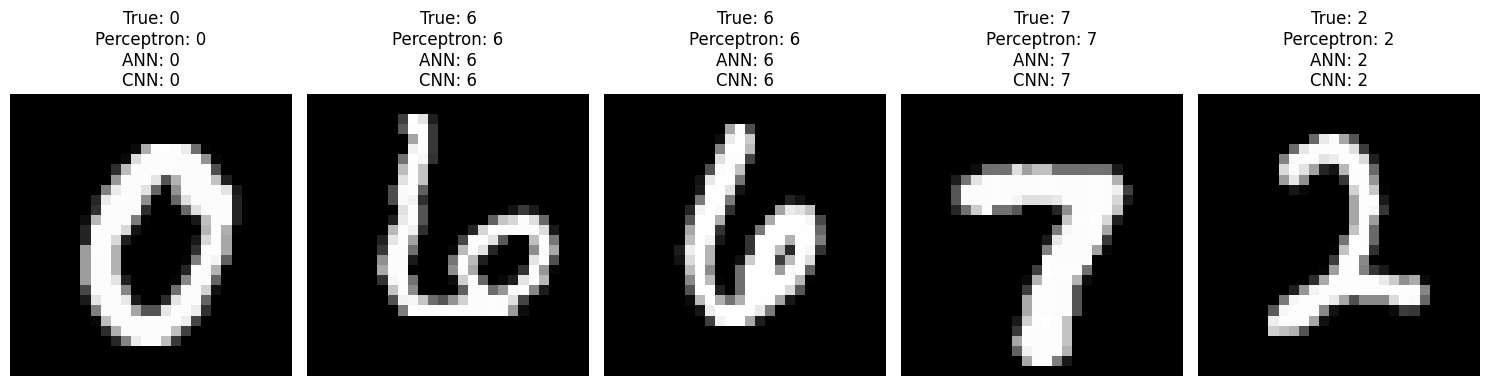

In [76]:
num_samples = 5
random_indices = np.random.choice(len(X_test_img), num_samples, replace=False)

plt.figure(figsize=(15, 8))
for i, idx in enumerate(random_indices):
    # Original Image
    img = X_test_img[idx]

    # True Label
    true_label = y_test[idx]

    # Model Predictions
    percp_pred = np.argmax(perceptron.predict(np.expand_dims(img, axis=0), verbose=0))
    ann_pred = np.argmax(ann.predict(np.expand_dims(img, axis=0), verbose=0))
    cnn_pred = np.argmax(cnn.predict(np.expand_dims(X_test_cnn[idx], axis=0), verbose=0))

    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {true_label}\nPerceptron: {percp_pred}\nANN: {ann_pred}\nCNN: {cnn_pred}")
    plt.axis('off')

plt.tight_layout()
plt.show()

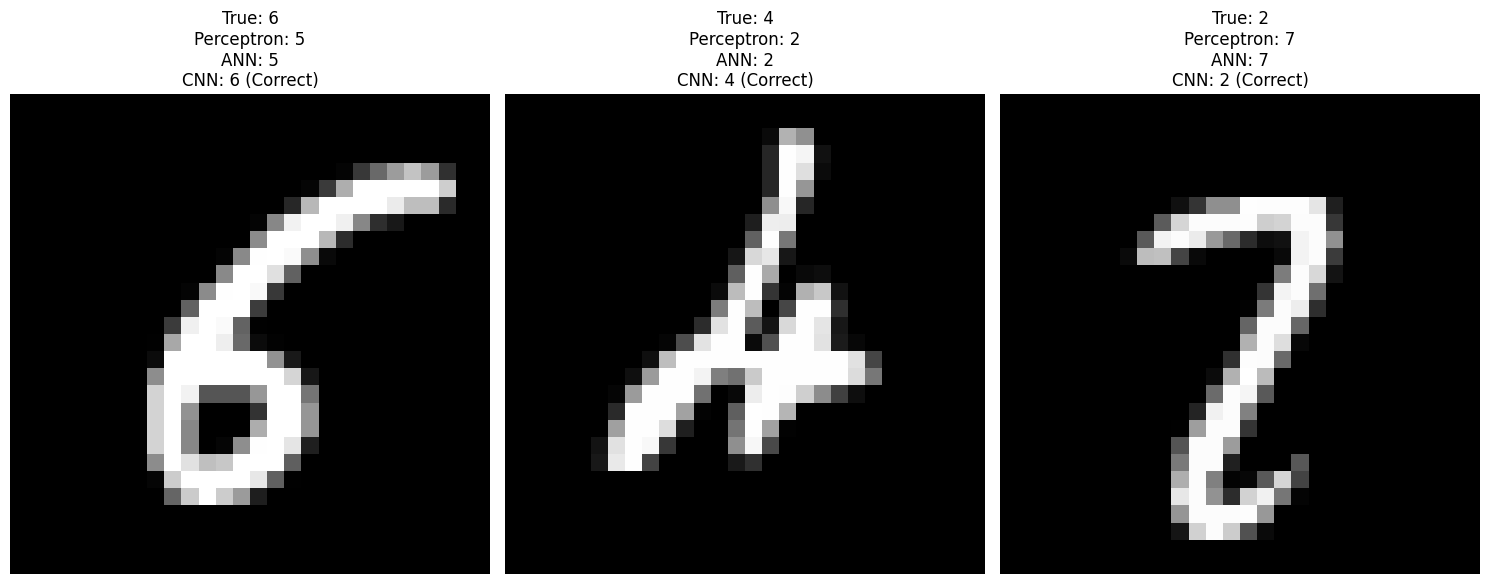

Found 3 samples where CNN was correct, but Perceptron and ANN were not. Indices: [217, 247, 321]


In [78]:
import numpy as np
import matplotlib.pyplot as plt

def find_cnn_only_correct_prediction(X_test_img, X_test_cnn, y_test, perceptron, ann, cnn, num_samples_to_show=1, max_samples_to_check=len(y_test)):
    """
    Finds and displays images from the test set that were correctly predicted
    by the CNN model, but incorrectly by the Perceptron and ANN models.
    """
    found_indices = []
    for idx in range(min(max_samples_to_check, len(y_test))):
        img = X_test_img[idx]
        true_label = y_test[idx]

        # Get predictions for all models
        percp_pred = np.argmax(perceptron.predict(np.expand_dims(img, axis=0), verbose=0))
        ann_pred = np.argmax(ann.predict(np.expand_dims(img, axis=0), verbose=0))
        cnn_pred = np.argmax(cnn.predict(np.expand_dims(X_test_cnn[idx], axis=0), verbose=0))

        # Check conditions
        if (cnn_pred == true_label) and \
           (percp_pred != true_label) and \
           (ann_pred != true_label):
            found_indices.append(idx)
            if len(found_indices) >= num_samples_to_show:
                break

    if found_indices:
        plt.figure(figsize=(15, 8))
        for i, idx in enumerate(found_indices):
            img = X_test_img[idx]
            true_label = y_test[idx]
            percp_pred = np.argmax(perceptron.predict(np.expand_dims(img, axis=0), verbose=0))
            ann_pred = np.argmax(ann.predict(np.expand_dims(img, axis=0), verbose=0))
            cnn_pred = np.argmax(cnn.predict(np.expand_dims(X_test_cnn[idx], axis=0), verbose=0))

            plt.subplot(1, len(found_indices), i + 1)
            plt.imshow(img, cmap='gray')
            plt.title(f"True: {true_label}\nPerceptron: {percp_pred}\nANN: {ann_pred}\nCNN: {cnn_pred} (Correct)")
            plt.axis('off')

        plt.tight_layout()
        plt.show()
        print(f"Found {len(found_indices)} samples where CNN was correct, but Perceptron and ANN were not. Indices: {found_indices}")
    else:
        print(f"No sample found within the first {max_samples_to_check} test samples where CNN was exclusively correct.")

# Call the function to find and display such an image (e.g., 3 samples)
find_cnn_only_correct_prediction(X_test_img, X_test_cnn, y_test, perceptron, ann, cnn, num_samples_to_show=3)
